In [11]:
# ─────────────────────────────────────────────
# [C1] Part 0. 오늘의 여정 · ⚙️ 환경 설정과 실습 데이터
# ─────────────────────────────────────────────

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install shap
import shap

from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_breast_cancer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("준비 완료 ✓", "SHAP", shap.__version__)

준비 완료 ✓ SHAP 0.52.0


In [12]:
# ─────────────────────────────────────────────
# [C2] Part 0. 오늘의 여정 · ⚙️ 환경 설정과 실습 데이터
# ─────────────────────────────────────────────
cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = (cancer.target == 0).astype(int)  # 이 노트북: 0=benign, 1=malignant
CLASS_NAMES = {0: "benign", 1: "malignant"}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    objective="binary:logistic",
    importance_type="gain",
    colsample_bytree=1.0,
    colsample_bylevel=1.0,
    colsample_bynode=1.0,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
).fit(X_train, y_train)

print("클래스 정의:", CLASS_NAMES)
print(f"테스트 정확도 = {accuracy_score(y_test, model.predict(X_test)):.3f}")
print(f"피처 {X.shape[1]}개, 트리 {model.n_estimators}개")

# 표본 1건이 XGBoost의 각 출력 형태를 통과하는 과정
one_sample = X_test.iloc[[0]]
raw_margin = model.predict(one_sample, output_margin=True)
class_probabilities = model.predict_proba(one_sample)
predicted_class = model.predict(one_sample)

print("\n[입력]")
print(f"one_sample.shape             = {one_sample.shape}  # 표본 × 피처")
print("\n[출력]")
print(f"raw_margin(log-odds).shape   = {raw_margin.shape}, value={raw_margin[0]:.4f}")
print(f"class_probabilities.shape    = {class_probabilities.shape}, "
      f"values={class_probabilities[0].round(4)}")
print(f"predicted_class.shape        = {predicted_class.shape}, "
      f"value={predicted_class[0]} ({CLASS_NAMES[int(predicted_class[0])]})")

클래스 정의: {0: 'benign', 1: 'malignant'}
테스트 정확도 = 0.965
피처 30개, 트리 200개

[입력]
one_sample.shape             = (1, 30)  # 표본 × 피처

[출력]
raw_margin(log-odds).shape   = (1,), value=-6.3696
class_probabilities.shape    = (1, 2), values=[0.9983 0.0017]
predicted_class.shape        = (1,), value=0 (benign)


In [13]:
# ─────────────────────────────────────────────
# [C3] Part 1 · 📊 데이터로 확인해 봅시다 — 200개 트리는 30개 피처를 어떻게 쓰는가
# ─────────────────────────────────────────────
booster = model.get_booster()
n_trees = len(booster.get_dump())
max_split_nodes = 2 ** model.max_depth - 1

print(f"전체 입력 피처: {X.shape[1]}개")
print(f"트리 수: {n_trees}개")
print(f"트리 최대 깊이: {model.max_depth}")
print(f"완전한 트리 한 그루의 최대 분기점: {max_split_nodes}개")
print("열 샘플링 비율:", {
    "bytree": model.colsample_bytree,
    "bylevel": model.colsample_bylevel,
    "bynode": model.colsample_bynode,
})
print("\n→ 각 분기점은 30개 피처를 후보로 검토해 Gain이 가장 큰")
print("  피처 하나와 기준값을 선택합니다. 같은 피처를 반복 사용할 수 있습니다.")

전체 입력 피처: 30개
트리 수: 200개
트리 최대 깊이: 4
완전한 트리 한 그루의 최대 분기점: 15개
열 샘플링 비율: {'bytree': 1.0, 'bylevel': 1.0, 'bynode': 1.0}

→ 각 분기점은 30개 피처를 후보로 검토해 Gain이 가장 큰
  피처 하나와 기준값을 선택합니다. 같은 피처를 반복 사용할 수 있습니다.


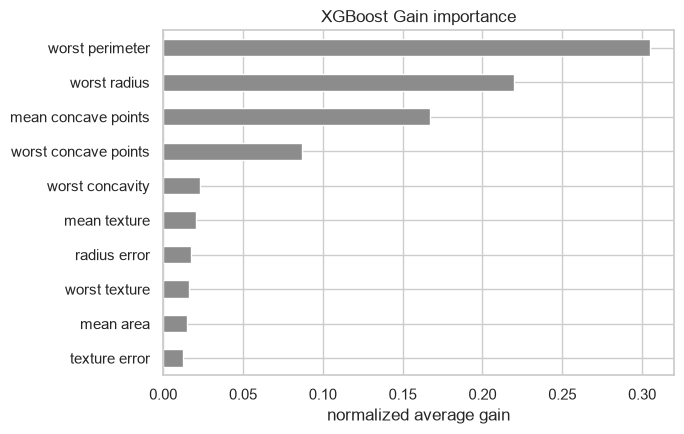

→ Gain은 이 피처를 사용한 분할이 평균적으로 손실을 얼마나 줄였는지 요약합니다.
→ 방향과 특정 환자의 예측 근거는 알려 주지 않습니다.


In [14]:
# ─────────────────────────────────────────────
# [C4] Part 2. Local에서 Global로 · 해석 방법 선택 · 📊 데이터로 확인해 봅시다 — 중요도의 한계를 직접 보기
# ─────────────────────────────────────────────
gain_importance = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values().tail(10)

plt.figure(figsize=(7, 4.5))
gain_importance.plot(kind="barh", color="#8c8c8c")
plt.title("XGBoost Gain importance")
plt.xlabel("normalized average gain")
plt.tight_layout()
plt.show()

print("→ Gain은 이 피처를 사용한 분할이 평균적으로 손실을 얼마나 줄였는지 요약합니다.")
print("→ 방향과 특정 환자의 예측 근거는 알려 주지 않습니다.")

🎯 [C4] 확인하기
현재 XGBoost의 feature_importances_는 기본 설정에서 Gain 중요도를 정규화한 값입니다. 모두 0 이상이므로 피처가 악성 확률을 높였는지 낮췄는지는 알 수 없습니다. RandomForest에서 흔히 보는 불순도 기반 중요도(MDI)와 모양은 비슷하지만 계산 기준이 같지 않습니다.

In [15]:
# [C5] Part 2. Local에서 Global로 · 해석 방법 선택 · 📊 데이터로 확인해 봅시다 — 중요도의 한계를 직접 보기
gain_importance = pd.Series(model.feature_importances_, index=X.columns)
permutation_result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE
)
permutation_importance_mean = pd.Series(
    permutation_result.importances_mean, index=X.columns
)

comparison = pd.DataFrame({
    "XGBoost Gain": gain_importance,
    "Permutation": permutation_importance_mean,
}).sort_values("Permutation", ascending=False).head(6)

print(comparison.round(4).to_string())
print("\nGain = 분할이 평균적으로 줄인 손실")
print("Permutation = 피처를 섞었을 때 줄어든 테스트 정확도")

                      XGBoost Gain  Permutation
worst texture               0.0164       0.0228
worst concavity             0.0233       0.0096
worst concave points        0.0871       0.0088
mean concave points         0.1671       0.0070
worst smoothness            0.0070       0.0044
worst area                  0.0122       0.0018

Gain = 분할이 평균적으로 줄인 손실
Permutation = 피처를 섞었을 때 줄어든 테스트 정확도


[문제]
XGBoost Gain과 순열 중요도가 같은 답을 주는지 확인합니다.

1) 두 중요도의 Top 5 피처가 몇 개 겹치는지 셉니다.
2) 두 순위의 차이가 가장 큰 피처 3개를 찾습니다.
3) 순열 중요도에 음수가 있다면 어떤 뜻인지 설명합니다.

(gain_importance, permutation_importance_mean을 사용합니다.)

In [16]:
# [C6] Part 2 · ⌨️ 백문이 불여일타! (1) — 두 중요도는 같은 답을 주는가

# 여기에 코드를 작성하세요
# 1) Top 5 피처가 몇 개 겹치는지
top5_gain = set(gain_importance.nlargest(5).index)
top5_perm = set(permutation_importance_mean.nlargest(5).index)

overlap = top5_gain & top5_perm
print("Gain Top5:", top5_gain)
print("Permutation Top5:", top5_perm)
print(f"겹치는 피처 수: {len(overlap)}개 → {overlap}")

# 2) 두 순위의 차이가 가장 큰 피처 3개
rank_gain = gain_importance.rank(ascending=False)
rank_perm = permutation_importance_mean.rank(ascending=False)

rank_diff = (rank_gain - rank_perm).abs().sort_values(ascending=False)
print("\n순위 차이 Top 3:")
print(rank_diff.head(3))

# 3) 순열 중요도에 음수가 있는지 확인
n_negative = (permutation_importance_mean < 0).sum()
print(f"\n음수인 피처 개수: {n_negative}개")
if n_negative > 0:
    print(permutation_importance_mean[permutation_importance_mean < 0])


Gain Top5: {'worst concave points', 'worst concavity', 'worst radius', 'worst perimeter', 'mean concave points'}
Permutation Top5: {'mean concave points', 'worst concave points', 'worst smoothness', 'worst texture', 'worst concavity'}
겹치는 피처 수: 3개 → {'worst concavity', 'mean concave points', 'worst concave points'}

순위 차이 Top 3:
worst perimeter    29.0
mean area          19.0
mean texture       18.0
dtype: float64

음수인 피처 개수: 9개
mean texture        -0.001754
mean area           -0.004386
mean smoothness     -0.002632
mean compactness    -0.000877
radius error        -0.001754
compactness error   -0.005263
symmetry error      -0.002632
worst perimeter     -0.007018
worst symmetry      -0.001754
dtype: float64


음수: 섞었더니 오히려 성능이 좋아짐 → 이건 이 피처가 오히려 모델을 살짝 헷갈리게 하고 있었거나(노이즈에 가까움), 그냥 우연(측정 오차, 랜덤성)일 가능성이 높다는 뜻

즉 음수는 "이 피처가 방해가 됐다"고 확신하기보다는, "이 피처는 사실상 중요하지 않다(0 근처의 잡음)" 정도로 해석하는 게 안전.

In [21]:
# ─────────────────────────────────────────────
# [C7] Part 3. SHAP 값의 원리 — 손으로 계산해 보기 · 📊 실제 모델로 확인하기 — `Explanation` 객체 만들기
# ─────────────────────────────────────────────
background = shap.sample(X_train, 100, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(
    model,
    feature_perturbation="tree_path_dependent",
    model_output="raw",
)
shap_explanation = explainer(X_test)
shap_values = shap_explanation.values

print("객체 유형:", type(shap_explanation).__name__)
print("SHAP 값 모양:", shap_values.shape, "= 표본 × 피처")
print("기준값 모양:", np.asarray(shap_explanation.base_values).shape)
print("피처명 예시:", list(shap_explanation.feature_names[:3]))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 표본 i의 raw margin 재구성 + 확률 변환
i = 0
z = shap_explanation.base_values[i] + shap_values[i].sum()
p1 = sigmoid(z)
print("raw margin:", z, "→ 확률:", p1)

객체 유형: Explanation
SHAP 값 모양: (114, 30) = 표본 × 피처
기준값 모양: (114,)
피처명 예시: ['mean radius', 'mean texture', 'mean perimeter']
raw margin: -6.3695726 → 확률: 0.001709962


In [22]:
# [C8] Part 3. SHAP 값의 원리 — 손으로 계산해 보기 · 📊 실제 모델로 확인하기 — `Explanation` 객체 만들기
sample_index = 0
base_probability = float(shap_explanation.base_values[sample_index])
shap_sum = float(shap_values[sample_index].sum())
reconstructed_probability = base_probability + shap_sum
predicted_probability = float(model.predict_proba(X_test.iloc[[sample_index]])[0, 1])

print(f"기준 악성 확률       = {base_probability:.6f}")
print(f"SHAP 값의 합         = {shap_sum:+.6f}")
print(f"기준값 + SHAP 합     = {reconstructed_probability:.6f}")
print(f"모델의 악성 확률     = {predicted_probability:.6f}")
print("합산성 확인          =", np.isclose(
    reconstructed_probability, predicted_probability, atol=1e-6
))

기준 악성 확률       = -0.537726
SHAP 값의 합         = -5.831847
기준값 + SHAP 합     = -6.369573
모델의 악성 확률     = 0.001710
합산성 확인          = False


In [23]:
# [C9] Part 3. SHAP 값의 원리 — 손으로 계산해 보기 · 📊 실제 모델로 확인하기 — `Explanation` 객체 만들기
sample_index = 0
contribution_table = pd.DataFrame({
    "feature_value": X_test.iloc[sample_index],
    "SHAP_value_probability": shap_values[sample_index],
})
contribution_table["direction"] = np.select(
    [
        contribution_table["SHAP_value_probability"] > 0,
        contribution_table["SHAP_value_probability"] < 0,
    ],
    ["malignant probability ↑", "malignant probability ↓"],
    default="no attributed contribution",
)
order = contribution_table["SHAP_value_probability"].abs().sort_values(ascending=False).index
print(contribution_table.loc[order].head(5).round(4).to_string())

                     feature_value  SHAP_value_probability                direction
worst texture              15.9700                 -1.5619  malignant probability ↓
worst area                510.5000                 -0.8144  malignant probability ↓
area error                 10.5000                 -0.7967  malignant probability ↓
mean concave points         0.0262                 -0.7853  malignant probability ↓
worst radius               12.8200                 -0.7408  malignant probability ↓


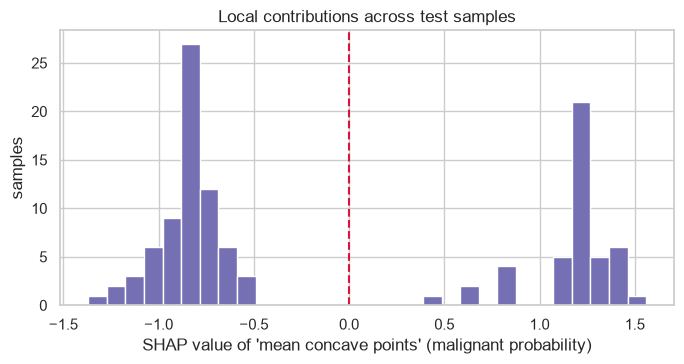

피처: mean concave points
악성 확률 증가 기여 표본: 45건
악성 확률 감소 기여 표본: 69건
Global mean(|SHAP|): 0.9724


In [24]:
# [C10] Part 3. SHAP 값의 원리 — 손으로 계산해 보기 · Local에서 Global로 — 왜 평균 절댓값을 쓰는가
global_shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X.columns
)
top_feature = global_shap_importance.idxmax()
feature_index = list(X.columns).index(top_feature)
feature_shap_values = shap_values[:, feature_index]

plt.figure(figsize=(7, 3.8))
plt.hist(feature_shap_values, bins=30, color="#7570b3", edgecolor="white")
plt.axvline(0, color="crimson", linestyle="--")
plt.xlabel(f"SHAP value of '{top_feature}' (malignant probability)")
plt.ylabel("samples")
plt.title("Local contributions across test samples")
plt.tight_layout()
plt.show()

print(f"피처: {top_feature}")
print(f"악성 확률 증가 기여 표본: {(feature_shap_values > 0).sum()}건")
print(f"악성 확률 감소 기여 표본: {(feature_shap_values < 0).sum()}건")
print(f"Global mean(|SHAP|): {np.abs(feature_shap_values).mean():.4f}")

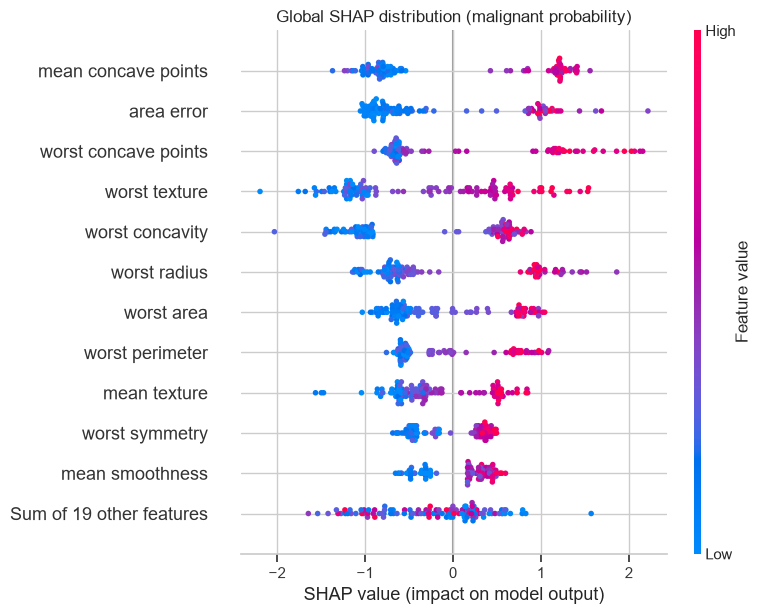

In [25]:
# [C11] Part 4. SHAP 시각화 — 질문에 맞는 그림 읽기 · 📊 데이터로 확인해 봅시다 — 네 장을 차례로 그려 보기
shap.plots.beeswarm(shap_explanation, max_display=12, show=False)
plt.title("Global SHAP distribution (malignant probability)")
plt.tight_layout()
plt.show()

🎯 [C11] 확인하기
점 하나는 표본 하나입니다. 오른쪽은 악성 확률 증가 기여, 왼쪽은 감소 기여입니다. 색은 실제 피처값의 크기입니다. 붉은 점이 오른쪽에 많다면 높은 피처값이 악성 확률 증가 기여와 함께 나타났다는 뜻이지 인과 효과를 증명한 것은 아닙니다.

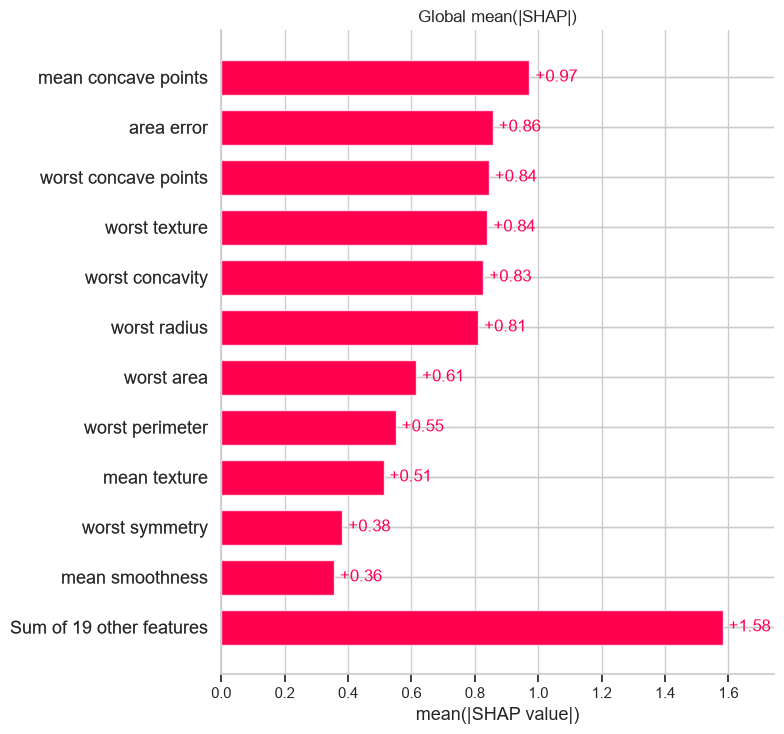

In [26]:
# [C12] Part 4. SHAP 시각화 — 질문에 맞는 그림 읽기 · 📊 데이터로 확인해 봅시다 — 네 장을 차례로 그려 보기
shap.plots.bar(shap_explanation, max_display=12, show=False)
plt.title("Global mean(|SHAP|)")
plt.tight_layout()
plt.show()

표본 0의 악성 예측 확률: 0.002


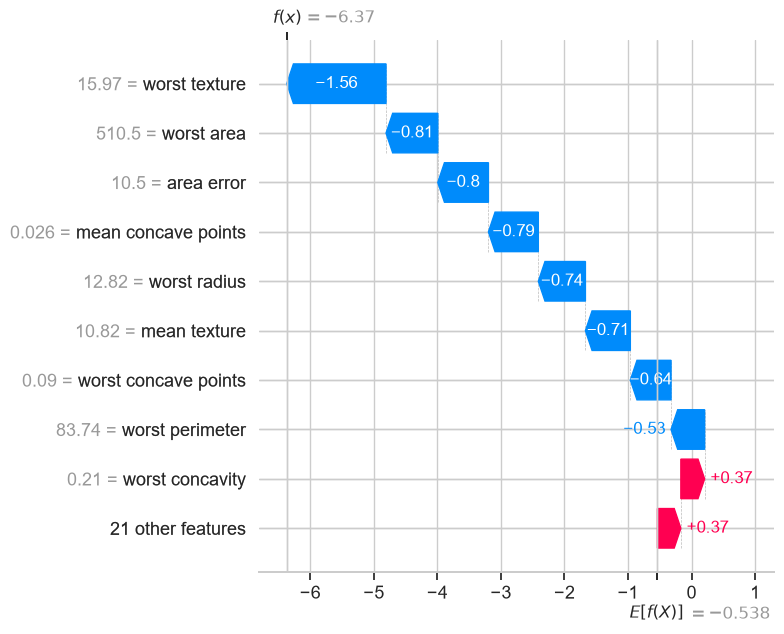

In [27]:
# [C13] Part 4. SHAP 시각화 — 질문에 맞는 그림 읽기 · 📊 데이터로 확인해 봅시다 — 네 장을 차례로 그려 보기
sample_index = 0
print(f"표본 {sample_index}의 악성 예측 확률: "
      f"{model.predict_proba(X_test.iloc[[sample_index]])[0, 1]:.3f}")
shap.plots.waterfall(shap_explanation[sample_index], max_display=10, show=False)
plt.tight_layout()
plt.show()

👀 [C13] 결과읽기
아래에서 위로 읽습니다. E[f(X)]는 배경 데이터에서의 기준 악성 확률, f(x)는 이 표본의 최종 악성 확률입니다. 붉은 기여는 악성 확률을 높이고 파란 기여는 낮춥니다. 작은 나머지 피처는 한 줄로 묶입니다.

highest malignant probability: sample 12, p=1.000


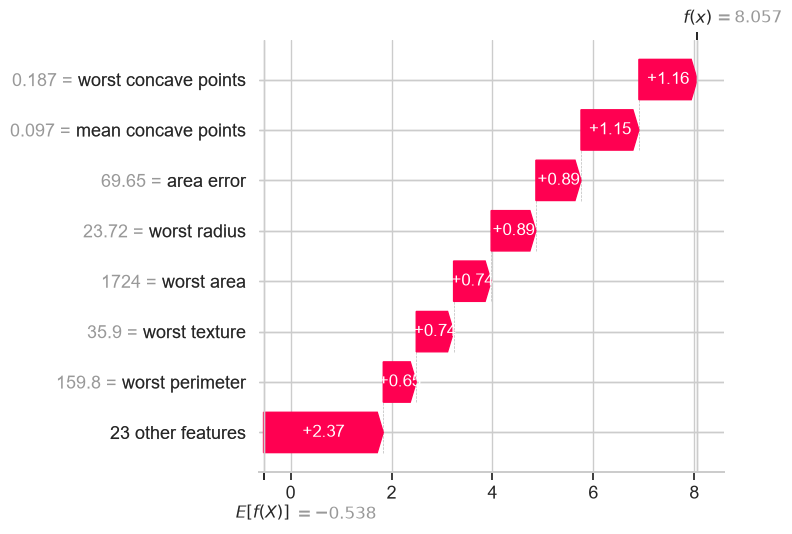

lowest malignant probability: sample 100, p=0.000


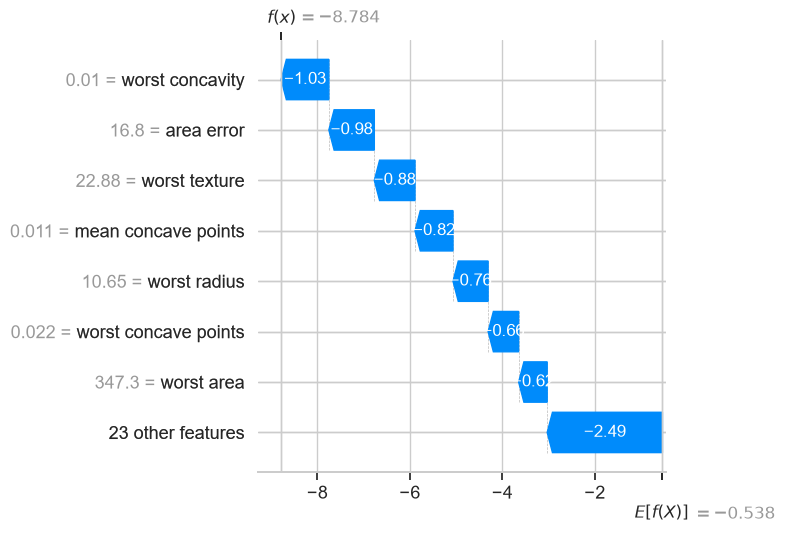

In [28]:
# [C14] Part 4. SHAP 시각화 — 질문에 맞는 그림 읽기 · 📊 데이터로 확인해 봅시다 — 네 장을 차례로 그려 보기
malignant_probabilities = model.predict_proba(X_test)[:, 1]
high_index = int(np.argmax(malignant_probabilities))
low_index = int(np.argmin(malignant_probabilities))

for label, index in [("highest", high_index), ("lowest", low_index)]:
    print(f"{label} malignant probability: sample {index}, "
          f"p={malignant_probabilities[index]:.3f}")
    shap.plots.waterfall(shap_explanation[index], max_display=8, show=False)
    plt.tight_layout()
    plt.show()

선택한 피처: mean concave points


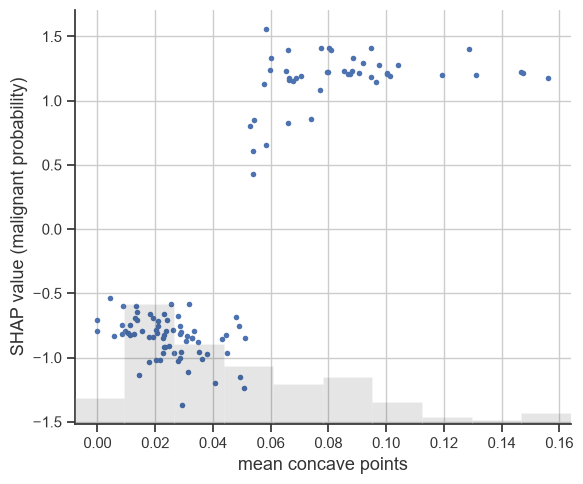

In [29]:
# [C15] Part 4. SHAP 시각화 — 질문에 맞는 그림 읽기 · 📊 데이터로 확인해 봅시다 — 네 장을 차례로 그려 보기
top_feature = np.abs(shap_explanation.values).mean(axis=0).argmax()
top_feature_name = shap_explanation.feature_names[top_feature]
print("선택한 피처:", top_feature_name)

shap.plots.scatter(
    shap_explanation[:, top_feature_name], color=None, show=False
)
plt.ylabel("SHAP value (malignant probability)")
plt.tight_layout()
plt.show()

[문제]
summary plot에서 눈으로 본 '좌우 퍼짐'을 숫자로 확인합니다.

1) 평균 |SHAP|이 큰 상위 3개 피처를 구합니다.
2) 각 피처마다 SHAP 값이 양수인 표본 수와 음수인 표본 수를 셉니다.
3) 셋 중 가장 '양쪽으로 갈리는' 피처는 무엇인지, 그것이 무엇을 뜻하는지 설명합니다.

(shap_values 는 SHAP 값 배열, X_test 는 테스트 세트입니다)

In [30]:
# [C16] Part 4 · ⌨️ 백문이 불여일타! (2) — 좌우 퍼짐을 숫자로 확인하기

# 여기에 코드를 작성하세요

# 1) 평균 |SHAP|이 큰 상위 3개 피처 찾기
mean_abs_shap = np.abs(shap_values).mean(axis=0)  # 피처별 평균 (axis=0 = 표본 방향으로 평균)

feature_importance = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=False)
top3_features = feature_importance.head(3).index.tolist()

print("평균 |SHAP| 상위 3개 피처:")
print(feature_importance.head(3))

# 2) 각 피처마다 양수/음수 표본 수 세기
rows = []
for feature_name in top3_features:
    col_idx = X_test.columns.get_loc(feature_name)
    col = shap_values[:, col_idx]

    n_positive = (col > 0).sum()
    n_negative = (col < 0).sum()

    rows.append({
        "feature": feature_name,
        "mean_abs_shap": mean_abs_shap[col_idx],
        "n_positive": n_positive,
        "n_negative": n_negative,
        "min_side_ratio": min(n_positive, n_negative) / (n_positive + n_negative)
    })

summary_df = pd.DataFrame(rows)
print("\n상위 3개 피처의 양수/음수 분포:")
print(summary_df)

# 3) 가장 '양쪽으로 갈리는' 피처 찾기
# min_side_ratio가 0.5에 가까울수록 양쪽으로 고르게 갈린다는 뜻
most_split_feature = summary_df.loc[summary_df["min_side_ratio"].idxmax(), "feature"]
print(f"\n가장 양쪽으로 갈리는 피처: {most_split_feature}")

평균 |SHAP| 상위 3개 피처:
mean concave points     0.972363
area error              0.856324
worst concave points    0.844117
dtype: float32

상위 3개 피처의 양수/음수 분포:
                feature  mean_abs_shap  n_positive  n_negative  min_side_ratio
0   mean concave points       0.972363          45          69        0.394737
1            area error       0.856324          36          78        0.315789
2  worst concave points       0.844117          37          77        0.324561

가장 양쪽으로 갈리는 피처: mean concave points


3) "가장 양쪽으로 갈리는" 피처가 의미하는 것

min_side_ratio가 0.5에 가까운 피처(양수/음수 개수가 거의 반반)가 가장 양쪽으로 갈리는 피처예요.

이게 뜻하는 바는: 이 피처는 값의 크기(높다/낮다)에 따라 예측 방향이 뒤집힌다는 거예요. 예를 들어 "종양 반경"이 이런 피처라면:

반경이 클수록 → SHAP 값 양수 (악성 확률 ↑)
반경이 작을수록 → SHAP 값 음수 (악성 확률 ↓)

즉, 요약 플롯(beeswarm)에서 점들이 좌우로 넓게 퍼져 있던 이유가 바로 이거예요 — 이 피처가 표본마다 반대 방향으로 작용하니까, 눈으로 봐도 점이 왼쪽(음수)과 오른쪽(양수)에 골고루 흩어져 있는 거예요.

반대로 항상 한쪽(양수든 음수든)에만 몰려 있는 피처는, "이 피처는 항상 한 방향으로만 위험도를 밀어준다"는 뜻이라 요약 플롯에서도 한쪽에만 점이 몰려 보였을 거예요.

In [31]:
# [C17] Part 5. 활용과 한계 — 설명을 과신하지 않기 · 📊 데이터로 확인해 봅시다 — 경계 표본 설명하기
malignant_probabilities = model.predict_proba(X_test)[:, 1]
border_index = int(np.argmin(np.abs(malignant_probabilities - 0.5)))
border_contributions = pd.Series(
    shap_values[border_index], index=X.columns
).sort_values(key=abs, ascending=False)

print(f"표본 {border_index}의 악성 확률: {malignant_probabilities[border_index]:.3f}")
print(border_contributions.head(5).round(4).to_string())
print("\n→ 설명은 확률의 구성 근거를 보여 주지만 예측의 정답 여부를 보증하지 않습니다.")

표본 69의 악성 확률: 0.618
worst concave points    1.8608
mean concave points     1.3915
worst texture          -1.1721
worst radius           -0.7924
worst concavity         0.5606

→ 설명은 확률의 구성 근거를 보여 주지만 예측의 정답 여부를 보증하지 않습니다.


In [41]:
# [C18] Part 5. 활용과 한계 — 설명을 과신하지 않기 · 📊 데이터로 확인해 봅시다 — 경계 표본 설명하기
rng = np.random.default_rng(RANDOM_STATE)
X_leak_train = X_train.copy()
X_leak_test = X_test.copy()
X_leak_train["leaky_target_copy"] = y_train.to_numpy() + rng.normal(0, 0.01, len(y_train))
X_leak_test["leaky_target_copy"] = y_test.to_numpy() + rng.normal(0, 0.01, len(y_test))

leaky_model = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    objective="binary:logistic", importance_type="gain",
    eval_metric="logloss", random_state=RANDOM_STATE,
).fit(X_leak_train, y_train)

leaky_background = shap.sample(X_leak_train, 100, random_state=RANDOM_STATE)
leaky_explanation = shap.TreeExplainer(
    leaky_model,
    data=leaky_background,
    feature_perturbation="interventional",
    model_output="probability",
)(X_leak_test)
leaky_importance = pd.Series(
    np.abs(leaky_explanation.values).mean(axis=0), index=X_leak_train.columns
).sort_values(ascending=False)

print("누수 피처 주입 후 SHAP 중요도 1위:", leaky_importance.index[0])
print(leaky_importance.head(3).round(4).to_string())

NotImplementedError: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.

[문제]
1) pick 값을 바꿔 환자 한 명을 고릅니다.
2) 악성 확률과 SHAP 기여 Top 5를 출력합니다.
3) "모델은 왜 이렇게 예측했는가"를 한 문장으로 쓰고 인과 해석이 아니라는 한계를 덧붙입니다.

In [ ]:
# [C19] Part 5 · ⌨️ 백문이 불여일타! (3) — pick을 바꿔 다른 환자의 예측 근거 설명

pick = 7                                   # 0 ~ (테스트 수-1) 사이로 바꿔보세요

# 여기에 코드를 작성하세요
malignant_prob = model.predict_proba(X_test)[:, 1][pick]
print(f"표본 {pick}의 악성 확률: {malignant_prob:.5f}")


# shap 기여 top 5 크기(절댓값) 기준으로 정렬

pick_contributions = pd.Series(
    shap_values[pick], index=X.columns
).sort_values(key=abs, ascending=False)

print(f"\n표본 {pick}의 SHAP 기여 Top 5:")
print(pick_contributions.head(5).round(4).to_string())

표본 7의 악성 확률: 0.00042

표본 7의 SHAP 기여 Top 5:
worst texture         -1.1415
worst concavity       -1.1054
area error            -0.9856
mean concave points   -0.9649
mean texture          -0.8636


In [40]:
top_feature = pick_contributions.index[0]
top_value = pick_contributions.iloc[0]
direction = "높이는" if top_value > 0 else "낮추는"

print(f"\n→ 모델은 이 환자에서 '{top_feature}'을(를) 비롯한 상위 피처들이 모두 "
      f"악성 확률을 낮추는 방향으로 작용해, 매우 낮은 확률({malignant_prob:.4f})로 "
      f"양성(benign)이라고 예측했다.")
print("   다만 이는 모델이 해당 피처들에 크게 의존해 이런 확률을 냈다는 뜻일 뿐, "
      "'worst texture'가 낮으면 실제로 암이 아니라는 의학적 인과관계를 증명하는 것은 아니다.")


→ 모델은 이 환자에서 'worst texture'을(를) 비롯한 상위 피처들이 모두 악성 확률을 낮추는 방향으로 작용해, 매우 낮은 확률(0.0004)로 양성(benign)이라고 예측했다.
   다만 이는 모델이 해당 피처들에 크게 의존해 이런 확률을 냈다는 뜻일 뿐, 'worst texture'가 낮으면 실제로 암이 아니라는 의학적 인과관계를 증명하는 것은 아니다.
